## Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Accessing Historical Data of Derivatives and Analysing Open Interest

So far, you have understood how to download data of equities. Now, you will download the historical data of derivatives. Here, we have also focussed on **Open Interest (OI)**, which shows the total number of outstanding contracts for an instrument.

This notebook will guide you on how to:
1.  Fetch historical data for expired Futures contracts.
2.  Retrieve and analyse Open Interest data.
3.  Visualise the relationship between price and Open Interest.

## Prerequisites

* **An Authenticated `kite` Object**: We will use a helper class for authentication.
* **Pandas & Matplotlib**: For data manipulation and creating insightful visualizations.

## Step 1: Authentication

First, we need to get an authenticated `kite` object to interact with the API.

In [ ]:
import pandas as pd
from kiteconnect import KiteConnect
import datetime
import matplotlib.pyplot as plt

# A helper class to manage Kite Connect authentication.
class KiteAuth:
    def __init__(self, api_key, api_secret):
        self.api_key, self.api_secret, self.kite = api_key, api_secret, None

    # Method to authenticate and generate a session.
    def authenticate(self):
        try:
            kite = KiteConnect(api_key=self.api_key)
            # Generate a login URL to get the request_token.
            print("Login URL: ", kite.login_url())
            request_token = input("Enter request_token: ").strip()

            # Generate a session using the request_token.
            data = kite.generate_session(request_token, api_secret=self.api_secret)

            # Set the access_token for future API calls.
            kite.set_access_token(data['access_token'])
            self.kite = kite
            print("Authentication Successful!")
            return kite
        except Exception as e:
            print(f"Auth Error: {e}")
            return None

# --- Start Authentication ---
# IMPORTANT: Replace with your own API Key and Secret.
API_KEY = "YOUR_API_KEY"
API_SECRET = "YOUR_API_SECRET"

kite = None
if API_KEY != "YOUR_API_KEY":
    auth = KiteAuth(API_KEY, API_SECRET)
    kite = auth.authenticate()
else:
    print("Please update your API_KEY and API_SECRET to run.")

Login URL:  https://kite.zerodha.com/connect/login?api_key=tj19jzf6vgdl162v&v=3
Enter request_token: i4aLtio4Bsj9jAX7YYLyFnOPvbN3qnNE
Authentication Successful!


## Step 2: Finding a Token for Historical Data

To analyse historical data for derivatives, it's important to understand how to access it correctly.

* **For Futures Contracts**: We use a 'continuous data' feature. This involves finding the `instrument_token` of a *currently active* contract to pull a stitched-together historical chart of its previously expired versions.

* **For Options Contracts**: Please note that historical candlestick data for specific, expired options contracts is **not available** via the Kite Connect API.

The following code finds the currently active front-month NIFTY futures contract. We will then use its token in the next steps.

In [ ]:
nfo_df = None
if kite:
    try:
        # Fetch all available instruments for the NFO (Futures & Options) segment.
        nfo_instruments = kite.instruments('NFO')
        nfo_df = pd.DataFrame(nfo_instruments)

        # The 'expiry' column is initially a string, so we convert it to a proper datetime format for filtering.
        nfo_df['expiry'] = pd.to_datetime(nfo_df['expiry'])
        print(f"Successfully fetched {len(nfo_df)} NFO instruments.")
    except Exception as e:
        print(f"Error fetching instruments: {e}")

if nfo_df is not None:
    # Get today's date to filter for contracts that have not yet expired.
    today = datetime.datetime.now()

    # Filter the DataFrame to find all active NIFTY futures contracts.
    nifty_futures_live = nfo_df[
        (nfo_df['name'] == 'NIFTY') &                  # Underlying is NIFTY
        (nfo_df['instrument_type'] == 'FUT') &         # Instrument is a Future
        (nfo_df['expiry'] > today)                     # Expiry date is in the future
    ]

    if not nifty_futures_live.empty:
        # Sort the active contracts by expiry date to find the nearest one (front-month).
        front_month_nifty_fut = nifty_futures_live.sort_values(by='expiry').iloc[0]

        print("\n--- Found Live NIFTY Future for Continuous Data ---")
        print("This token will be used to fetch historical data of past contracts.")
        print(front_month_nifty_fut[['tradingsymbol', 'instrument_token', 'expiry']])
    else:
        print("\nCould not find any active NIFTY futures contracts.")

Successfully fetched 35723 NFO instruments.

--- Found Live NIFTY Future for Continuous Data ---
This token will be used to fetch historical data of past contracts.
tradingsymbol             NIFTY25JUNFUT
instrument_token               14536962
expiry              2025-06-26 00:00:00
Name: 0, dtype: object


## Step 3: Understanding Open Interest (OI)

Open Interest is a measure of the total number of outstanding derivative contracts that have not been settled. For every buyer of a futures or options contract, there must be a seller. The total of all these pairs is the open interest.

**Why is it important?**
* **Liquidity:** High OI indicates a liquid and active market.
* **Sentiment:** Changes in OI, when combined with price movements, can signal market sentiment. For example:
    * **Price Up, OI Up:** New money is coming into the market, suggesting a bullish trend (Long Buildup).
    * **Price Down, OI Up:** New shorts are entering the market, suggesting a bearish trend (Short Buildup).
    * **Price Up, OI Down:** Traders are closing their short positions, suggesting a weakening downtrend (Short Covering).
    * **Price Down, OI Down:** Traders are closing their long positions, suggesting a weakening uptrend (Long Unwinding).

## Step 4: Fetching Historical Data with Open Interest

Now we use the `instrument_token` of the live contract found in Step 2. The key is to set two important parameters in our `historical_data` call:

1.  `oi=True`: To include Open Interest in the response.
2.  `continuous=True`: To get the stitched historical data for expired futures.

In [ ]:
# Check if the 'front_month_nifty_fut' variable was created successfully in the previous step.
if 'front_month_nifty_fut' in locals():
    # Get the token from the live contract we identified.
    live_token = front_month_nifty_fut['instrument_token']

    # Define the HISTORICAL period you want to analyse.
    # For this example, we fetch data for May 2024.
    from_date = datetime.date(2024, 5, 1)
    to_date = datetime.date(2024, 5, 31)

    try:
        print(f"Fetching continuous daily data for NIFTY Futures from {from_date} to {to_date} with OI...")

        # Make the API call for historical data.
        # continuous=True tells the API to create a continuous chart from past contracts.
        # oi=True tells the API to include Open Interest data.
        historical_data_with_oi = kite.historical_data(live_token, from_date, to_date, 'day', continuous=True, oi=True)

        # Convert the list of dictionaries returned by the API into a pandas DataFrame for easier analysis.
        oi_df = pd.DataFrame(historical_data_with_oi)
        # Convert the 'date' column to datetime objects and set it as the index for time-series plotting.
        oi_df['date'] = pd.to_datetime(oi_df['date'])
        oi_df.set_index('date', inplace=True)

        print(f"Successfully fetched {len(oi_df)} days of data.")
        # Display the first few rows of the resulting DataFrame.
        display(oi_df.head())
    except Exception as e:
        print(f"Error fetching historical data with OI: {e}")

Fetching continuous daily data for NIFTY Futures from 2024-05-01 to 2024-05-31 with OI...
Successfully fetched 22 days of data.


,open,high,low,close,volume,oi
date,,,,,,
2024-05-02 00:00:00+05:30,22702.05,22808.40,22688.05,22773.95,4801075,11047500
2024-05-03 00:00:00+05:30,22850.00,22888.35,22470.00,22575.20,10956050,10451150
2024-05-06 00:00:00+05:30,22648.70,22686.40,22510.00,22550.15,5992500,11047300
2024-05-07 00:00:00+05:30,22545.00,22590.95,22312.60,22381.80,7018025,10622675
2024-05-08 00:00:00+05:30,22344.00,22490.00,22286.15,22393.85,7488875,10746375


## Step 5: Visualizing Price vs. Open Interest

A dual-axis plot is an excellent way to see the relationship between price and open interest over time.

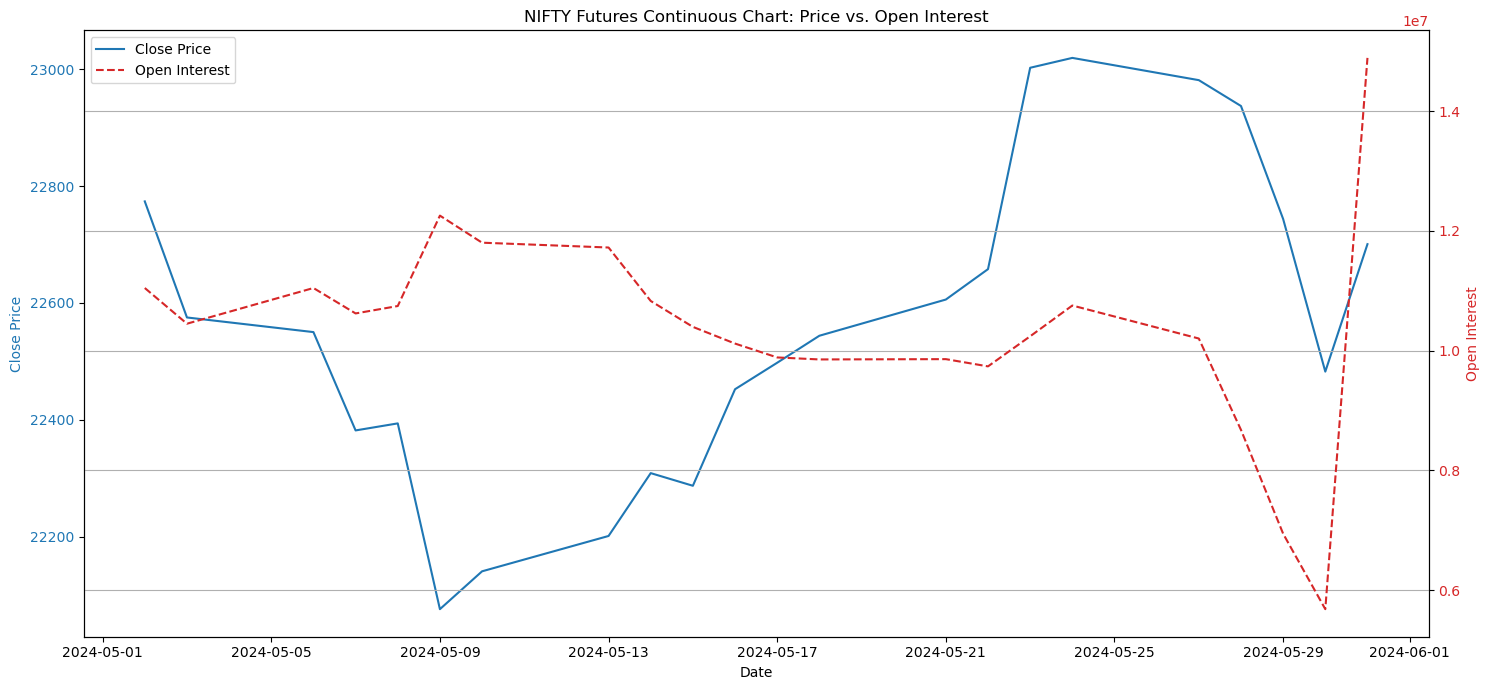

In [ ]:
# Check if the DataFrame 'oi_df' exists and is not empty before attempting to plot.
if 'oi_df' in locals() and not oi_df.empty:
    # Create a figure and a primary y-axis for the plot.
    fig, ax1 = plt.subplots(figsize=(15, 7))

    ax1.set_title(f'NIFTY Futures Continuous Chart: Price vs. Open Interest')
    ax1.set_xlabel('Date')

    # ---- Plot 1: Close Price on the Left Y-Axis ----
    color = 'tab:blue'
    ax1.set_ylabel('Close Price', color=color)
    ax1.plot(oi_df.index, oi_df['close'], color=color, label='Close Price')
    ax1.tick_params(axis='y', labelcolor=color)

    # ---- Plot 2: Open Interest on the Right Y-Axis ----
    # Create a second y-axis that shares the same x-axis.
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Open Interest', color=color)
    ax2.plot(oi_df.index, oi_df['oi'], color=color, linestyle='--', label='Open Interest')
    ax2.tick_params(axis='y', labelcolor=color)

    # --- Formatting and Legend ---
    fig.tight_layout() # Adjust layout to prevent labels from overlapping.
    # Add a unified legend for both plots.
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.grid(True)
    plt.show()

## Conclusion

You have now learned how to fetch and analyse historical data with open interest for expired futures contracts. This is a powerful technique for backtesting strategies that rely on market sentiment and participation.

**Key Takeaways:**
* For **expired futures**, you must use the `instrument_token` of a **live contract** and make the API call with the `continuous=True` flag.
* Historical data for specific **expired options contracts** is not available.
* By plotting price against OI, you can gain a deeper understanding of market dynamics, such as identifying periods of strong trend conviction or trend exhaustion. <br><br>